# Intervention A — choosing the sentence-embedding model

Intervention A replaces TF-IDF with a pretrained sentence encoder for **one** part of the item
representation: the item's own descriptive prose (`title` + `blurb`). Everything else is held
fixed — `creator` and `taxonomy` keep their atomic-entity TF-IDF blocks, `reviews` keeps its
word TF-IDF block, and the hybrid, the frozen user profile and the evaluation are all unchanged.
See `recsys/intervention_a.py` for why each role goes where it goes.

This notebook answers only: **which encoder?** It does not report a result. The winner is written
to `../outputs/hyperparams.json` and the steel thread picks it up from there.

**The instrument is deliberately identical to `hyperparameter_tuning.ipynb`'s.** Selection happens
on `dataset.cold_val` — a second, disjoint cold population drawn from the same eligible pool by the
same rule as the reported test set, and likewise absent from `ref_train`. Nothing here ever touches
`dataset.cold_item_ids`. Fitting is on `ref_train`, exactly as in the steel thread.

**Each encoder gets its own lambda.** The content term is divided by its own measured spread
(`s_cb`), so lambda is roughly comparable across representations — but only roughly, and the
optimal value genuinely tracks content quality. Comparing six encoders at one shared lambda would
risk crowning whichever one happened to suit it. So every encoder is swept over the same lambda
grid and judged at its own best **feasible** value. Lambda is nearly free once a model's content
block is cached, so this costs one extra content block per model, not one per (model, lambda).

**There is no TF-IDF row here.** The baseline is not a candidate — it is the thing Intervention A
will be compared against later, through the full instrument on the cold *test* population at the
full seed ensemble. Putting a 2-seed cold_val number for TF-IDF in this table would invite exactly
the wrong comparison.

In [1]:
%%time
import gc
import hashlib
import json
import os
import pickle
import sys
import time

sys.path.insert(0, "..")

import numpy as np
import matplotlib
try:
    get_ipython()
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from recsys import load, cf, content, cbhcf, intervention_a as ia, eval as ev

DEVICE = "cuda:1"
DATA_PATH = "../data/filtered/books_5core_common.parquet"
SPLIT_PARAMS = dict(cold_item_fraction=0.10, cold_val_fraction=0.10)
EMBED_DIR = "../data/embeddings"


def cache_pickle(name, compute, params=None):
    tag = "" if params is None else "_" + hashlib.md5(repr(params).encode()).hexdigest()[:8]
    path = f"../data/cache/{name}{tag}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    val = compute()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(val, f, protocol=pickle.HIGHEST_PROTOCOL)
    return val


dataset = cache_pickle("books_dataset", lambda: load.load_dataset(data_path=DATA_PATH, **SPLIT_PARAMS),
                       params=load.load_params_fingerprint(DATA_PATH, **SPLIT_PARAMS))
FP = load.dataset_fingerprint(dataset)
if dataset.cold_val is None:
    raise RuntimeError("this dataset has no validation cold population; rebuild with cold_val_fraction > 0")
val = dataset.cold_val
print(f"test cold items {len(dataset.cold_item_ids):,}   validation cold items {len(val.cold_item_ids):,}")
print(f"dataset fingerprint: {FP}")

/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/implicit/gpu/__init__.py:28: UserWarning: Disabling GPU support because of '/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/implicit/gpu/_cuda.so: undefined symbol: _ZN3rmm13device_bufferC1EmNS_16cuda_stream_viewENS_6detail23cccl_async_resource_refIN4cuda2mr3__412resource_refIJNS6_17device_accessibleEEEEEE'
  warnings.warn(


test cold items 2,727   validation cold items 2,727
dataset fingerprint: (384339, 487790, 2676601, 345998, 347561, 2727, 633483902, 13635, 2727, 625156242)
CPU times: user 933 ms, sys: 925 ms, total: 1.86 s
Wall time: 1.23 s


## The slate

Six encoders, chosen under one hard constraint: **every context window is at least 1024 tokens.**
The document being encoded (`title` + `blurb`) runs to 243 tokens on average with p99 at 813, so a
1024-token floor puts ~p99 inside every model's window and removes window size as a confound. That
ruled out several otherwise-obvious candidates — MiniLM (256), mpnet (384), and the 512-token
`bge-base-en-v1.5` / `e5-base-v2` / `mxbai-embed-large-v1`.

Two more were ruled out by this environment rather than by design: `gte-*-en-v1.5` and
`jina-embeddings-v3` both fail to run under transformers 5.14 (their pinned remote code indexes a
RoPE table out of bounds / references an attribute the new API dropped), and
`google/embeddinggemma-300m` is a gated repo. `gte-modernbert-base` replaces the gte-v1.5 family;
the `Qwen3-Embedding` pair supplies the within-family size comparison (0.6B vs 4B) that
`gte-base` vs `gte-large` was going to provide.

All six are encoded at **bfloat16** with `max_seq_length=1024`. The cap is free (0.26% of items
truncated, top-10 item-neighbour lists 100% identical to an 8192-token reference). bf16 is not
free — it perturbs ~4% of top-10 neighbours — but `Qwen3-Embedding-4B` cannot be loaded in fp32 on
a 24 GB card at all, and a uniform dtype means that perturbation applies equally to every model
and so cannot favour one over another.

In [2]:
%%time
SLATE = list(ia.ENCODERS)

print(f"{'key':<22}{'repo':<44}{'dim':>6}{'embeddings':>13}")
missing = []
for key in SLATE:
    spec = ia.ENCODERS[key]
    p = ia.embedding_path(key, "books", EMBED_DIR)
    ok = os.path.exists(p)
    missing += [] if ok else [key]
    print(f"{key:<22}{spec.repo:<44}{spec.dim:>6}"
          f"{(f'{os.path.getsize(p) / 1e9:.2f} GB' if ok else 'MISSING'):>13}")
if missing:
    raise RuntimeError(
        f"no Books embeddings for {missing}. Run on the GPU box, from the repo root:\n"
        f"    for m in {' '.join(missing)}; do PYTHONPATH=. python encode_intervention_a.py --model $m; done")

key                   repo                                           dim   embeddings
gte-modernbert-base   Alibaba-NLP/gte-modernbert-base                768      0.77 GB
nomic-v1.5            nomic-ai/nomic-embed-text-v1.5                 768      0.77 GB
bge-m3                BAAI/bge-m3                                   1024      1.02 GB
arctic-l-v2.0         Snowflake/snowflake-arctic-embed-l-v2.0       1024      1.02 GB
qwen3-0.6b            Qwen/Qwen3-Embedding-0.6B                     1024      1.02 GB
qwen3-4b              Qwen/Qwen3-Embedding-4B                       2560      2.52 GB
CPU times: user 0 ns, sys: 1.77 ms, total: 1.77 ms
Wall time: 1.17 ms


## Fixed apparatus — shared by every encoder

The ALS fits, the candidate pools, the eval-user sets and the warm-item guard are built once and
reused across the whole slate. That is what makes this a comparison of *representations*: the only
thing that varies between rows of the results table is the item content matrix.

**The warm-item guard.** `cold_val` measures only cold-item retrieval, so an objective built on it
alone is blind to what a large lambda does to everything else — and left unconstrained it climbs
monotonically toward pure content, because discarding the collaborative signal costs nothing that
`cold_val` can see. The same lambda applies to the whole catalogue in reality, and warm items are
exactly where the collaborative signal is strong. So: maximize cold-item retrieval **subject to**
warm-item NDCG on `ref_val` staying within `WARM_TOLERANCE` of the best warm score that model
achieves anywhere on the grid. The reference is per-model best, not the pure-ALS control, for the
reason recorded in `hyperparameter_tuning.py`: content *improves* warm retrieval here, so
anchoring to lambda=0 makes the constraint vacuous.

In [3]:
%%time
SELECTOR = "NDCG"
K = 100
K_LEVELS_TUNE = [0, 2, 5, 10, 20]
CEILING_WEIGHT = 1.0
N_SEEDS_TUNE = 2
ALS_PARAMS = dict(factors=64, regularization=0.01, iterations=20)
# Resolution where the decision actually happens. CBHCF's cold objective rises MONOTONICALLY with
# lambda (0.00108 at 0 -> 0.04927 at 1e6, no interior optimum), so the selected value is set entirely
# by where the warm-item guard bites -- for TF-IDF that was lambda=2.0, with 3.0 already infeasible.
# A grid that jumps 2 -> 4 -> 8 would straddle that boundary and resolve it to whichever side it
# happened to sample. This mirrors hyperparameter_tuning.py's spacing through the feasible region
# and extends to 16 in case an encoder's warm curve declines more slowly than TF-IDF's.
LAMBDA_GRID = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0, 16.0]
# Reported alongside the per-encoder selection: CBHCF's own tuned lambda, so the table also shows
# how the slate ranks at ONE shared value. If the two rankings agree, the choice of lambda is not
# what decided the winner -- which is worth knowing either way.
CBHCF_LAMBDA = 2.0
# AUC during the lambda grid. Off: it is a cross-check rather than the selector, and it costs ~70%
# of each grid point (measured 161s per lambda with it, ~86s without). Re-measured with AUC at the
# selected lambda only -- see the end of the sweep loop.
SWEEP_WITH_AUC = False
# Encoders whose content block is NOT persisted to disk -- see the sweep cell for why. Keyed by
# encoder rather than by a dimension threshold so the reason stays legible: this is the one model
# whose memory profile broke the run.
SKIP_DISK_CACHE = {"qwen3-4b"}
WARM_TOLERANCE = 0.02
N_WARM_EVAL = 10_000

# The same fits hyperparameter_tuning.ipynb uses -- same cache key, so this is free if that has run.
als_seeds = cache_pickle(
    "als_seeds_tune",
    lambda: [cf.ALSModel(random_state=s, **ALS_PARAMS).fit(dataset.ref_train)
             for s in range(N_SEEDS_TUNE)],
    params=(FP, tuple(sorted(ALS_PARAMS.items())), N_SEEDS_TUNE))
for m in als_seeds:
    m.prepare_gpu_recommend(val, candidates="warm_cold", device=DEVICE)
print(f"{len(als_seeds)} ALS fits ready (candidate pool: {len(als_seeds[0]._candidate_ids):,} items)")

warm_item_ids = np.unique(dataset.ref_train.nonzero()[1])
eval_users_val = np.flatnonzero(np.diff(val.test_matrix.tocsr().indptr))

# The warm guard needs content scores for its sampled ref_val users too, so each content cache has
# to cover the UNION. A fixed random sample stands in for all 347k users with a held-out warm
# interaction -- large enough that NDCG@K is stable well inside the tolerance being tested.
_warm_pool = np.flatnonzero(np.diff(dataset.ref_val.tocsr().indptr))
warm_eval_users = np.sort(np.random.default_rng(0).choice(
    _warm_pool, min(N_WARM_EVAL, len(_warm_pool)), replace=False))
_keep = np.zeros(dataset.n_users, dtype=bool)
_keep[warm_eval_users] = True
# .multiply() with a dense mask writes zeros into .data but keeps the sparsity STRUCTURE, so
# un-sampled rows still register in indptr as "has a held-out item" and mode_a_metrics_at_k would
# try to score all 347k of them -- most outside the content cache. eliminate_zeros() is required.
ref_val_sample = dataset.ref_val.multiply(_keep[:, None]).tocsr()
ref_val_sample.eliminate_zeros()
assert np.flatnonzero(np.diff(ref_val_sample.indptr)).size == len(warm_eval_users)
cache_users = np.union1d(eval_users_val, warm_eval_users)

print(f"eval users on cold_val: {len(eval_users_val):,}   "
      f"warm guard users (from ref_val): {len(warm_eval_users):,}   "
      f"content cache covers {len(cache_users):,}")


def objective(row, metric=SELECTOR):
    """Mean over the reveal levels AND the within-item ceiling.

    The ceiling is what stops the selector from chasing k=0 performance at the expense of
    well-observed cold items -- at k=0 a cold item's collaborative score is exactly zero, so nothing
    counterweighs pushing lambda up, and a value chosen there would be actively harmful at large k.
    """
    vals = list(row["by_k"][metric]) + [row["ceiling"][metric]] * int(round(CEILING_WEIGHT))
    return float(np.nanmean(vals))

2 ALS fits ready (candidate pool: 246,687 items)
eval users on cold_val: 12,264   warm guard users (from ref_val): 10,000   content cache covers 21,899
CPU times: user 427 ms, sys: 379 ms, total: 807 ms
Wall time: 808 ms


## The sweep

One pass per encoder: build its content space, cache the content block once, then sweep lambda
over that cache.

`build_mode_b=False` is a real saving, not a micro-optimization. Mode B (every user × the cold
items) is several minutes and ~2 GB per encoder, and *nothing in this notebook reads it* —
`sweep_mode_a_cached` and `ceiling_reference` are both Mode A. It is built in the steel thread,
where the item-to-user view is actually reported.

Each encoder's dense block is 1–5 GB, so a space is released before the next one is built. Holding
all six would be ~14 GB of host memory for no reason.

In [4]:
%%time
# Per-encoder checkpoint. This loop is ~2 hours, and losing all of it to an interruption is a bad
# trade when each encoder's result is independent of the others -- as happened on 2026-08-01, when
# the WSL VM went down mid-run (host sleep) and took 20 minutes of completed work with it, because
# nbconvert --inplace only writes the notebook at the very end.
#
# The checkpoint is keyed on everything that would change a result: the dataset fingerprint, the
# lambda grid, the seed count and the content-space definition. Change any of them and it starts
# clean rather than mixing results computed under different rules.
CKPT_PATH = "../outputs/intervention_a_selection_checkpoint.json"
CKPT_KEY = {"fingerprint": list(FP), "lambda_grid": LAMBDA_GRID, "seeds": N_SEEDS_TUNE,
            "k_levels": K_LEVELS_TUNE, "selector": SELECTOR, "K": K,
            "text_weight": ia.DEFAULT_TEXT_WEIGHT, "max_seq_length": ia.MAX_SEQ_LEN,
            "encode_dtype": ia.TORCH_DTYPE, "warm_tolerance": WARM_TOLERANCE,
            "n_warm_eval": N_WARM_EVAL, "sweep_with_auc": SWEEP_WITH_AUC}

results = {}
if os.path.exists(CKPT_PATH):
    with open(CKPT_PATH) as f:
        blob = json.load(f)
    if blob.get("key") == CKPT_KEY:
        results = blob["results"]
        print(f"resuming: {len(results)}/{len(SLATE)} encoders already done "
              f"({', '.join(results) or 'none'})")
    else:
        print(f"checkpoint at {CKPT_PATH} was written under different settings -- ignoring it "
              f"and recomputing from scratch.")


def save_checkpoint():
    os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
    with open(CKPT_PATH, "w") as f:
        # default=float: the metric means arrive as numpy scalars, which json cannot serialize.
        json.dump({"key": CKPT_KEY, "results": results}, f, default=float)


for key in SLATE:
    if key in results:
        print(f"\n{'=' * 78}\n{key}: loaded from checkpoint "
              f"(lambda {results[key]['best_lambda']:g}, objective "
              f"{results[key]['best_objective']:.5f})\n{'=' * 78}", flush=True)
        continue
    t_model = time.perf_counter()
    print(f"\n{'=' * 78}\n{key}  ({ia.ENCODERS[key].repo}, dim {ia.ENCODERS[key].dim})\n{'=' * 78}",
          flush=True)

    space = ia.build_space(dataset, key, catalogue="books", fit_rows=warm_item_ids,
                           embed_dir=EMBED_DIR, data_root="..", verbose=True)

    # ~10.8 GB per encoder (21,899 users x 246,687 candidates at float16), so ~65 GB for the slate.
    # Kept on disk: it is built once per encoder per run (~110 s) and reread in ~20-40 s, so it pays
    # for itself the first time this notebook is re-run -- which a grid change, a kernel restart or
    # a seventh encoder all trigger.
    #
    # The KEY must cover everything the block depends on, or a re-run silently reuses a stale one.
    # cbhcf guards the eval-user set (it compares the stored array and refuses a mismatch), but it
    # cannot know about the content space: change text_weight, min_df, the sparse roles, the
    # sequence cap or the encode dtype and the vectors change while the filename would not. Those
    # go in the hash. This is the same discipline as `cache_pickle`'s fingerprints -- the failure it
    # prevents is silent and would look like a real result.
    #
    # EXCEPT for the encoders in SKIP_DISK_CACHE. Pickling a 10.8 GB float16 block needs the array
    # AND a serialization buffer -- roughly double -- and reading it back needs the same again. On
    # top of a 2,560-dim encoder's 5 GB dense block that was the high-water mark of the whole run,
    # and qwen3-4b killed the process three times at exactly this step (no guest OOM, no traceback:
    # the WSL distro went down under it). Rebuilding on the GPU instead costs ~110 s and allocates
    # in chunks. The five 768/1024-dim encoders are unaffected and keep their caches.
    space_fp = (FP, len(cache_users), key, ia.DEFAULT_TEXT_WEIGHT, ia.MAX_SEQ_LEN,
                ia.TORCH_DTYPE, ia.TEXT_ROLES, ia.SPARSE_ROLES, "mindf2")
    cache_path = (None if key in SKIP_DISK_CACHE else
                  f"../data/cache/ia_content_{key}_"
                  f"{hashlib.md5(repr(space_fp).encode()).hexdigest()[:10]}.pkl")
    base_models = cbhcf.wrap_seeds(
        als_seeds, dataset.ref_train, space, cache_users, content_weight=1.0, gpu_device=DEVICE,
        build_mode_b=False, cache_path=cache_path)

    rows = []
    for lam in LAMBDA_GRID:
        t0 = time.perf_counter()
        models = [m.with_content_weight(lam) for m in base_models]
        # with_auc=False during the grid. Measured, AUC is ~70% of the sweep's cost (105s of 161s
        # per lambda), and it is NOT the selector -- `objective` reads NDCG only, and AUC is a
        # cross-check. Computing it at all ten grid points and then reporting one of them wastes
        # ~1.3 h across the slate. It is recomputed below at each encoder's SELECTED lambda, which
        # is the only place the cross-check is read.
        curve, _ = ev.sweep_mode_a_cached(models, val, K_LEVELS_TUNE, K=K, verbose=False,
                                          with_auc=SWEEP_WITH_AUC)
        ceil = ev.ceiling_reference(models, val, K=K)
        # Seed 0 only: this is a constraint, not a headline number, and warm quality is not
        # seed-sensitive at a level that matters for a 2% threshold.
        warm = ev.mode_a_metrics_at_k(models[0], dataset.ref_train, ref_val_sample, K=K)
        rows.append({"lambda": lam,
                     "by_k": {met: list(curve[met]["mean"]) for met in ev.METRICS},
                     "ceiling": {met: ceil["mean"][met] for met in ev.METRICS},
                     "warm": {met: warm[met] for met in ["NDCG", "Precision", "Recall", "HitRate"]},
                     "seconds": time.perf_counter() - t0})
        print(f"  lambda={lam:<7g} {SELECTOR}@k: "
              + " ".join(f"{v:.4f}" for v in curve[SELECTOR]["mean"])
              + f"   ceiling {ceil['mean'][SELECTOR]:.4f}"
              + f"   obj {objective(rows[-1]):.5f}"
              + f"   warm {warm[SELECTOR]:.4f}   ({rows[-1]['seconds']:.0f}s)", flush=True)

    scores = [objective(r) for r in rows]
    warm_scores = [r["warm"][SELECTOR] for r in rows]
    warm_ref = max(warm_scores)
    warm_floor = warm_ref * (1.0 - WARM_TOLERANCE)
    feasible = [i for i, w in enumerate(warm_scores) if w >= warm_floor]
    unconstrained_i = int(np.nanargmax(scores))
    best_i = max(feasible, key=lambda i: scores[i]) if feasible else unconstrained_i

    # The AUC cross-check, at the selected lambda only. AUC matters here because NDCG@100 over a
    # 246,687-item pool saturates near zero for cold items (see the k=0 column above), so a
    # rank-based metric is the one that can still distinguish two encoders that both look like
    # ~0.03. One extra evaluation per encoder rather than ten.
    sel_models = [m.with_content_weight(rows[best_i]["lambda"]) for m in base_models]
    sel_curve, _ = ev.sweep_mode_a_cached(sel_models, val, K_LEVELS_TUNE, K=K, verbose=False,
                                          with_auc=True)
    auc_by_k = list(sel_curve["AUC"]["mean"])
    print(f"  AUC@k at lambda={rows[best_i]['lambda']:g}: "
          + " ".join(f"{v:.4f}" for v in auc_by_k), flush=True)

    results[key] = {"rows": rows, "scores": scores, "warm_scores": warm_scores,
                    "auc_by_k_at_best": auc_by_k, "auc_mean_at_best": float(np.nanmean(auc_by_k)),
                    "warm_ref": warm_ref, "warm_floor": warm_floor,
                    "best_lambda": rows[best_i]["lambda"], "best_objective": scores[best_i],
                    "best_warm": warm_scores[best_i],
                    "constraint_was_binding": bool(best_i != unconstrained_i),
                    "unconstrained_lambda": rows[unconstrained_i]["lambda"],
                    "dim": ia.ENCODERS[key].dim, "repo": ia.ENCODERS[key].repo,
                    "minutes": (time.perf_counter() - t_model) / 60}
    print(f"  -> best lambda {rows[best_i]['lambda']:g}   objective {scores[best_i]:.5f}   "
          f"warm {warm_scores[best_i]:.5f}"
          + ("   (warm constraint BINDING)" if best_i != unconstrained_i else "")
          + f"   [{results[key]['minutes']:.1f} min]", flush=True)

    save_checkpoint()          # after EVERY encoder, so an interruption costs at most one
    del base_models, space
    gc.collect()

resuming: 5/6 encoders already done (gte-modernbert-base, nomic-v1.5, bge-m3, arctic-l-v2.0, qwen3-0.6b)

gte-modernbert-base: loaded from checkpoint (lambda 1.5, objective 0.02674)

nomic-v1.5: loaded from checkpoint (lambda 1.5, objective 0.02284)

bge-m3: loaded from checkpoint (lambda 2, objective 0.02999)

arctic-l-v2.0: loaded from checkpoint (lambda 3, objective 0.03696)

qwen3-0.6b: loaded from checkpoint (lambda 2, objective 0.03165)

qwen3-4b  (Qwen/Qwen3-Embedding-4B, dim 2560)
[intervention_a] qwen3-4b: 487,790/487,790 items embedded (dim 2560)
role          kind     vocab     fit nnz  nonempty(fit)  weight
creator     entity    35,220     199,391         78.57%    1.00
taxonomy    entity       631     719,789         98.58%    0.50
reviews       text   287,756  55,108,414         77.98%    0.50
TOTAL                323,607
[intervention_a] space: dense (487790, 2560) (weight 1.4142135623730951) + sparse (487790, 323607)  -> 326,167 features   items with no text vector: 0
[

## The comparison

`lambda=0` is pure ALS and is in the grid for every encoder, so its objective must come out
identical down the column — the content term is multiplied by zero. A discrepancy there would mean
the harness is not actually holding the collaborative side fixed, and would invalidate the whole
table. It is checked, not eyeballed.

In [5]:
%%time
zero_objs = [results[k]["scores"][LAMBDA_GRID.index(0.0)] for k in SLATE] if 0.0 in LAMBDA_GRID else []
if zero_objs and (max(zero_objs) - min(zero_objs)) > 1e-9:
    raise RuntimeError(f"lambda=0 (pure ALS) differs across encoders: {dict(zip(SLATE, zero_objs))}. "
                       "The collaborative side is not being held fixed -- the comparison is invalid.")
als_floor = zero_objs[0] if zero_objs else float("nan")
print(f"pure-ALS control (lambda=0), identical across all encoders: {als_floor:.5f}\n")

order = sorted(SLATE, key=lambda k: -results[k]["best_objective"])
fixed_i = LAMBDA_GRID.index(CBHCF_LAMBDA)
print(f"{'encoder':<22}{'dim':>5}{'lambda*':>9}{'cold obj':>11}{'vs ALS':>9}"
      f"{'AUC@k0':>9}{'warm ' + SELECTOR:>12}{'binding':>9}{'obj@l=' + str(CBHCF_LAMBDA):>12}{'min':>7}")
for k in order:
    r = results[k]
    lift = (r["best_objective"] / als_floor - 1) * 100 if als_floor > 0 else float("nan")
    print(f"{k:<22}{r['dim']:>5}{r['best_lambda']:>9g}{r['best_objective']:>11.5f}{lift:>8.1f}%"
          f"{r['auc_by_k_at_best'][0]:>9.4f}{r['best_warm']:>12.5f}"
          f"{'yes' if r['constraint_was_binding'] else '-':>9}"
          f"{r['scores'][fixed_i]:>12.5f}{r['minutes']:>7.1f}")

# NDCG and AUC should agree on the ordering. Where they don't, NDCG@100 is probably saturating and
# AUC is the more informative metric -- worth surfacing rather than silently ranking on NDCG.
order_auc = sorted(SLATE, key=lambda k: -results[k]["auc_mean_at_best"])
if order_auc != order:
    print(f"\nNOTE: ranking by AUC differs from NDCG: {' > '.join(order_auc)}")
    print("  NDCG@100 saturates near zero for cold items, so a disagreement here means the NDCG "
          "gap is small enough to be worth checking against the rank-based metric.")

# Does per-encoder lambda actually change the verdict? If the ranking at CBHCF's shared lambda=2.0
# matches the ranking at each encoder's own selected value, then the sweep did not decide the
# winner, and a fixed lambda would have been just as defensible (and simpler to describe).
order_fixed = sorted(SLATE, key=lambda k: -results[k]["scores"][fixed_i])
if order_fixed == order:
    print(f"\nranking at the shared lambda={CBHCF_LAMBDA:g} is IDENTICAL to the per-encoder ranking "
          f"-- the sweep did not decide the winner.")
else:
    print(f"\nranking DIFFERS at the shared lambda={CBHCF_LAMBDA:g}: {' > '.join(order_fixed)}")
    print(f"  vs per-encoder lambda:                          {' > '.join(order)}")
    print("  -> the per-encoder sweep is load-bearing here; a single shared lambda would have "
          "picked a different model.")

# The warm guard is only meaningful if it was actually measurable -- flag any encoder whose entire
# grid sits below its own warm floor, where `feasible` was empty and the fallback took over.
for k in SLATE:
    if results[k]["best_lambda"] == results[k]["unconstrained_lambda"] and \
            results[k]["best_warm"] < results[k]["warm_floor"]:
        print(f"  WARNING {k}: no grid point satisfied the warm guard; reported at the "
              f"unconstrained optimum.")

BEST_MODEL = order[0]
BEST_LAMBDA = results[BEST_MODEL]["best_lambda"]
runner_up = order[1]
margin = (results[BEST_MODEL]["best_objective"] / results[runner_up]["best_objective"] - 1) * 100
print(f"\nselected: {BEST_MODEL}  (lambda {BEST_LAMBDA:g}, objective "
      f"{results[BEST_MODEL]['best_objective']:.5f})")
print(f"  margin over {runner_up}: {margin:.2f}%")
if margin < 1.0:
    print("  NOTE: under 1% separates the top two. At 2 seeds that is inside the noise this "
          "notebook can resolve -- prefer the cheaper/smaller model unless the steel thread "
          "confirms the gap at the full ensemble.")

pure-ALS control (lambda=0), identical across all encoders: 0.00108

encoder                 dim  lambda*   cold obj   vs ALS   AUC@k0   warm NDCG  binding   obj@l=2.0    min
arctic-l-v2.0          1024        3    0.03696  3312.7%   0.7865     0.05074      yes     0.03544   28.3
qwen3-4b               2560        2    0.03241  2892.5%   0.7957     0.04799      yes     0.03241   23.3
qwen3-0.6b             1024        2    0.03165  2822.4%   0.7771     0.04856      yes     0.03165   28.7
bge-m3                 1024        2    0.02999  2669.2%   0.7740     0.04436      yes     0.02999   28.3
gte-modernbert-base     768      1.5    0.02674  2369.2%   0.7770     0.04375      yes     0.02741   23.2
nomic-v1.5              768      1.5    0.02284  2009.5%   0.7722     0.04037      yes     0.02342   27.2

NOTE: ranking by AUC differs from NDCG: qwen3-4b > arctic-l-v2.0 > gte-modernbert-base > qwen3-0.6b > nomic-v1.5 > bge-m3
  NDCG@100 saturates near zero for cold items, so a disagreement h

## Is the selection robust?

Two things worth seeing before freezing a choice. Left: the objective against lambda for every
encoder — if the curves are broad and well separated, the ranking is about the representation; if
they cross repeatedly, the winner is an artefact of where the grid happens to sample. Right: the
winner's warm-item constraint, which is the only thing stopping lambda from climbing indefinitely.

CPU times: user 375 ms, sys: 31.6 ms, total: 407 ms
Wall time: 413 ms


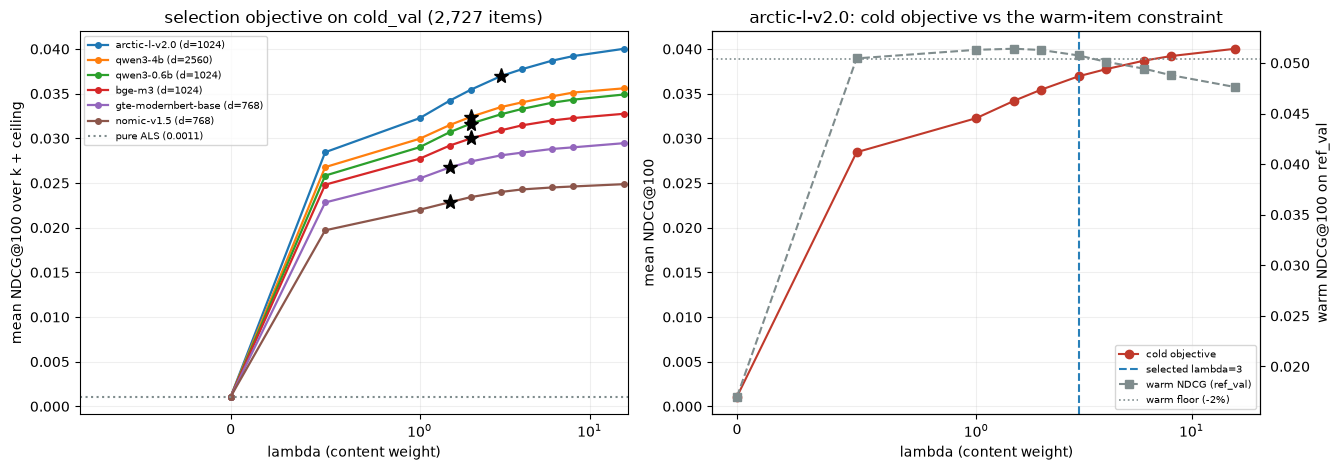

In [6]:
%%time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8))
for k in order:
    r = results[k]
    ax1.plot(LAMBDA_GRID, r["scores"], "o-", label=f"{k} (d={r['dim']})", linewidth=1.6, markersize=4)
    ax1.plot([r["best_lambda"]], [r["best_objective"]], "k*", markersize=11, zorder=5)
ax1.axhline(als_floor, color="#7f8c8d", linestyle=":", label=f"pure ALS ({als_floor:.4f})")
ax1.set_xscale("symlog", linthresh=1.0)
ax1.set_xlabel("lambda (content weight)")
ax1.set_ylabel(f"mean {SELECTOR}@{K} over k + ceiling")
ax1.set_title(f"selection objective on cold_val ({len(val.cold_item_ids):,} items)")
ax1.grid(alpha=0.2)
ax1.legend(fontsize=7)

r = results[BEST_MODEL]
ax2.plot(LAMBDA_GRID, r["scores"], "o-", color="#c0392b", label="cold objective")
ax2.axvline(BEST_LAMBDA, color="#2980b9", linestyle="--", label=f"selected lambda={BEST_LAMBDA:g}")
ax2.set_xscale("symlog", linthresh=1.0)
ax2.set_xlabel("lambda (content weight)")
ax2.set_ylabel(f"mean {SELECTOR}@{K}")
ax2.set_title(f"{BEST_MODEL}: cold objective vs the warm-item constraint")
ax2.grid(alpha=0.2)
ax2w = ax2.twinx()
ax2w.plot(LAMBDA_GRID, r["warm_scores"], "s--", color="#7f8c8d", label=f"warm {SELECTOR} (ref_val)")
ax2w.axhline(r["warm_floor"], color="#7f8c8d", linestyle=":", linewidth=1.2,
             label=f"warm floor (-{WARM_TOLERANCE:.0%})")
ax2w.set_ylabel(f"warm {SELECTOR}@{K} on ref_val")
h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2w.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig("intervention_a_model_selection.png", dpi=120, bbox_inches="tight")

## Persist the selection

Stamped with the dataset fingerprint, so the steel thread can refuse it if the split has changed —
the same guard `hyperparameter_tuning.ipynb` writes for CBHCF's lambda.

The full per-encoder grid is kept, not just the winner. If the steel thread later shows the
selected encoder underperforming, the question "was the runner-up close?" should be answerable
without a 5-hour rerun.

In [7]:
%%time
os.makedirs("../outputs", exist_ok=True)
path = "../outputs/hyperparams.json"
record = json.load(open(path)) if os.path.exists(path) else {}
record["intervention_a"] = {
    "model_key": BEST_MODEL,
    "model_repo": ia.ENCODERS[BEST_MODEL].repo,
    "embedding_dim": ia.ENCODERS[BEST_MODEL].dim,
    "content_weight": BEST_LAMBDA,
    "text_weight": ia.DEFAULT_TEXT_WEIGHT,
    "text_roles": list(ia.TEXT_ROLES),
    "sparse_roles": list(ia.SPARSE_ROLES),
    "max_seq_length": ia.MAX_SEQ_LEN,
    "encode_dtype": ia.TORCH_DTYPE,
    "selected_on": (f"cold_val ({len(val.cold_item_ids):,} items), mean {SELECTOR}@{K} over "
                    f"k={K_LEVELS_TUNE} + within-item ceiling, {N_SEEDS_TUNE} seeds, per-encoder "
                    f"lambda, subject to warm {SELECTOR}@{K} on ref_val within "
                    f"{WARM_TOLERANCE:.0%} of that encoder's best warm score"),
    "lambda_grid": LAMBDA_GRID,
    "als_floor_objective": als_floor,
    "margin_over_runner_up_pct": margin,
    "shared_lambda_reference": CBHCF_LAMBDA,
    "ranking_agrees_at_shared_lambda": order_fixed == order,
    "per_model": {k: {"repo": results[k]["repo"], "dim": results[k]["dim"],
                      "best_lambda": results[k]["best_lambda"],
                      "best_objective": results[k]["best_objective"],
                      "objective_at_shared_lambda": results[k]["scores"][fixed_i],
                      "auc_by_k_at_best_lambda": results[k]["auc_by_k_at_best"],
                      "best_warm_ndcg": results[k]["best_warm"],
                      "constraint_was_binding": results[k]["constraint_was_binding"],
                      "objective_by_lambda": dict(zip(map(str, LAMBDA_GRID), results[k]["scores"])),
                      "warm_ndcg_by_lambda": dict(zip(map(str, LAMBDA_GRID),
                                                      results[k]["warm_scores"]))}
                  for k in SLATE},
    "seeds": N_SEEDS_TUNE,
    "als_params": ALS_PARAMS,
    "dataset_fingerprint": list(FP),
    "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S"),
}
with open(path, "w") as f:
    json.dump(record, f, indent=2)
print(f"wrote {path}: intervention_a.model_key = {BEST_MODEL}, content_weight = {BEST_LAMBDA:g}")

wrote ../outputs/hyperparams.json: intervention_a.model_key = arctic-l-v2.0, content_weight = 3
CPU times: user 1.05 ms, sys: 645 μs, total: 1.69 ms
Wall time: 1.13 ms
